In [54]:
import pandas as pd

In [55]:
import tensorflow as tf

In [56]:
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np

In [57]:
tf.config.experimental.list_physical_devices()

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]

In [58]:
tf.__version__

'2.18.0'

In [59]:
tf.test.is_built_with_cuda()

False

In [60]:
(x_train,y_train) ,(x_test,y_test) = tf.keras.datasets.cifar10.load_data()

In [61]:
print(x_train.shape)
print(y_train.shape)

(50000, 32, 32, 3)
(50000, 1)


In [62]:
def plot_sample(index):
    plt.figure(figsize=(10,1))
    plt.imshow(x_train[index])

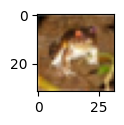

In [63]:
plot_sample(0)

In [64]:
classes = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]

In [65]:
y_train[1][0]

np.uint8(9)

In [66]:
np.unique(y_train)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [67]:
classes[y_train[0][0]]

'frog'

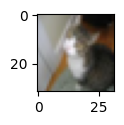

In [68]:
plot_sample(101)

In [69]:
classes[y_train[101][0]]

'cat'

### **Scalling Images: -**

In [70]:
x_train_scaled = x_train / 255
x_test_scaled = x_test / 255

In [71]:
x_train_scaled

array([[[[0.23137255, 0.24313725, 0.24705882],
         [0.16862745, 0.18039216, 0.17647059],
         [0.19607843, 0.18823529, 0.16862745],
         ...,
         [0.61960784, 0.51764706, 0.42352941],
         [0.59607843, 0.49019608, 0.4       ],
         [0.58039216, 0.48627451, 0.40392157]],

        [[0.0627451 , 0.07843137, 0.07843137],
         [0.        , 0.        , 0.        ],
         [0.07058824, 0.03137255, 0.        ],
         ...,
         [0.48235294, 0.34509804, 0.21568627],
         [0.46666667, 0.3254902 , 0.19607843],
         [0.47843137, 0.34117647, 0.22352941]],

        [[0.09803922, 0.09411765, 0.08235294],
         [0.0627451 , 0.02745098, 0.        ],
         [0.19215686, 0.10588235, 0.03137255],
         ...,
         [0.4627451 , 0.32941176, 0.19607843],
         [0.47058824, 0.32941176, 0.19607843],
         [0.42745098, 0.28627451, 0.16470588]],

        ...,

        [[0.81568627, 0.66666667, 0.37647059],
         [0.78823529, 0.6       , 0.13333333]

In [72]:
y_train

array([[6],
       [9],
       [9],
       ...,
       [9],
       [1],
       [1]], dtype=uint8)

### **One hot Encoding: -**

In [73]:
y_train_categorical = keras.utils.to_categorical(y_train,num_classes=10)
y_test_categorical = keras.utils.to_categorical(y_test,num_classes=10)

In [74]:
y_train

array([[6],
       [9],
       [9],
       ...,
       [9],
       [1],
       [1]], dtype=uint8)

In [75]:
y_train_categorical

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.]])

In [76]:
print(32*32*3)

3072


### **Model Trainning : -**

In [83]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(32,32,3)),
    keras.layers.Dense(3000,activation = 'relu'),
    keras.layers.Dense(1000,activation = 'relu'),
    keras.layers.Dense(10,activation = 'sigmoid')
])
model.compile(optimizer = 'SGD',
            loss = 'categorical_crossentropy',
            metrics = ['accuracy']
            )
model.fit(x_train_scaled,y_train_categorical,epochs = 10)

/Users/yuvrajbhatkariya/data/VScode.C++/Python/myenv/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 26s 17ms/step - accuracy: 0.3036 - loss: 1.9339
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - accuracy: 0.4202 - loss: 1.6422
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 190s 122ms/step - accuracy: 0.4546 - loss: 1.5492
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 27s 17ms/step - accuracy: 0.4766 - loss: 1.4918
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 27s 17ms/step - accuracy: 0.4926 - loss: 1.4399
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 26s 16ms/step - accuracy: 0.5080 - loss: 1.3982
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 25s 16ms/step - accuracy: 0.5279 - loss: 1.3461
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 26s 17ms/step - accuracy: 0.5388 - loss: 1.3260
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 26s 17ms/step - accuracy: 0.5495 - loss: 1.2880
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 26s 17ms/step - accuracy: 0.5607 - loss: 1.2513


In [94]:
model.predict(x_test_scaled)[990]

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


array([0.70105636, 0.9386902 , 0.32183263, 0.5888343 , 0.08544403,
       0.39867148, 0.2691239 , 0.08061816, 0.6563506 , 0.74670184],
      dtype=float32)

In [96]:
classes[np.argmax(model.predict(x_test_scaled)[990])]

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


'automobile'

In [97]:
classes[y_test[990][0]]

'automobile'

### **Cheking speed of cpu and gpu: -**



In [98]:
def get_model():
    model = keras.Sequential([
            keras.layers.Flatten(input_shape=(32,32,3)),
            keras.layers.Dense(3000, activation='relu'),
            keras.layers.Dense(1000, activation='relu'),
            keras.layers.Dense(10, activation='sigmoid')    
        ])

    model.compile(optimizer='SGD',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

### **Time for GPU: -**

In [ ]:
%%timeit -n1 -r1
with tf.device('/GPU:0'):
    cpu_model = get_model()
    cpu_model.fit(X_train_scaled, y_train_categorical, epochs=1)

/Users/yuvrajbhatkariya/data/VScode.C++/Python/myenv/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 26s 16ms/step - accuracy: 0.3060 - loss: 1.9293
30.7 s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


### **Time for CPU: -**

In [100]:
%%timeit -n1 -r1 
with tf.device('/CPU:0'):
    cpu_model = get_model()
    cpu_model.fit(X_train_scaled, y_train_categorical, epochs=1)

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 27s 17ms/step - accuracy: 0.3056 - loss: 1.9314
27.9 s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)
